## My Question.

### One question I could ask is, how does the HP of generations 1-5 compare to the HP of generations 6-9 Pokémon?

## My study

### My study is an observational study because im comparing two groups pokemon generatins 1-5 and generations 6-9 within this sample i now have and im comparing them on a shared characteristic which is HP.

### Notes: import the essentials! copy paste from last notebook seems where this one is going just need to rename things. Make histogram comparing the two datasets do not do one for each generation thats not the question.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('pokemon.csv')

In [4]:
df.head

<bound method NDFrame.head of       national_number gen  english_name   japanese_name primary_type  \
0                   1   I     Bulbasaur     Fushigidane        grass   
1                   2   I       Ivysaur      Fushigisou        grass   
2                   3   I      Venusaur     Fushigibana        grass   
3                   4   I    Charmander        Hitokage         fire   
4                   5   I    Charmeleon         Lizardo         fire   
...               ...  ..           ...             ...          ...   
1020             1021  IX   Raging Bolt     Takeruraiko     electric   
1021             1022  IX  Iron Boulder     Tetsunoiwao         rock   
1022             1023  IX    Iron Crown  Tetsunokashira        steel   
1023             1024  IX     Terapagos       Terapagos       normal   
1024             1025  IX     Pecharunt       Momowarou       poison   

     secondary_type       classification  percent_male  percent_female  \
0            poison         See

In [5]:
df["hp"].value_counts()

hp
60     78
70     73
50     65
40     53
65     53
       ..
33      1
154     1
94      1
87      1
155     1
Name: count, Length: 107, dtype: int64

In [6]:
gen_map = {
    'I': 'Gen 1-5', 'II': 'Gen 1-5', 'III': 'Gen 1-5', 'IV': 'Gen 1-5', 'V': 'Gen 1-5',
    'VI': 'Gen 6-9', 'VII': 'Gen 6-9', 'VIII': 'Gen 6-9', 'IX': 'Gen 6-9'
}

# Clean missing HP and create grouped era column
plot_df = df.dropna(subset=['hp']).copy()
plot_df['gen_group'] = plot_df['gen'].map(gen_map)

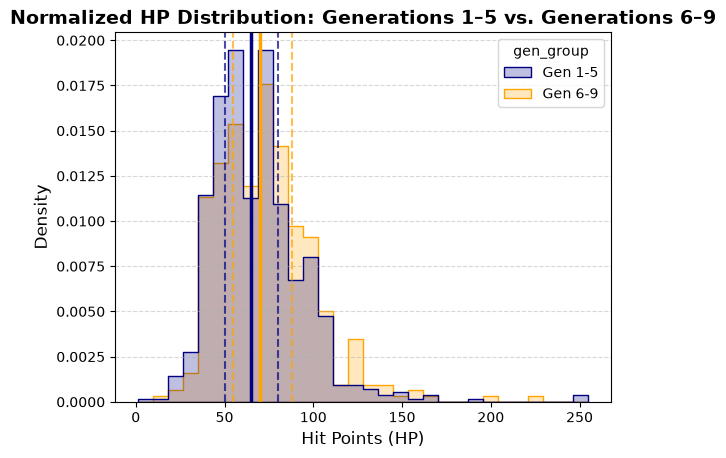

In [7]:
sns.histplot(
    data=plot_df,
    x='hp',
    hue='gen_group',  # Use the mapped column here
    element='step',
    stat='density',
    common_norm=False,
    bins=30,
    palette={'Gen 1-5': 'navy', 'Gen 6-9': 'orange'}
)
g1_hp = plot_df[plot_df['gen_group'] == 'Gen 1-5']['hp']
med_g1 = g1_hp.median()
q1_g1 = g1_hp.quantile(0.25)
q3_g1 = g1_hp.quantile(0.75)

plt.axvline(med_g1, color='navy', linestyle='-', linewidth=2.5, label=f'Gen 1-5 Median ({med_g1:.1f})')
plt.axvline(q1_g1, color='navy', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Gen 1-5 IQR ({q1_g1:.1f}–{q3_g1:.1f})')
plt.axvline(q3_g1, color='navy', linestyle='--', linewidth=1.5, alpha=0.7)

# 5. Calculate and draw Median & IQR (Q1 / Q3) lines for Gen 6-9
g2_hp = plot_df[plot_df['gen_group'] == 'Gen 6-9']['hp']
med_g2 = g2_hp.median()
q1_g2 = g2_hp.quantile(0.25)
q3_g2 = g2_hp.quantile(0.75)

plt.axvline(med_g2, color='orange', linestyle='-', linewidth=2.5, label=f'Gen 6-9 Median ({med_g2:.1f})')
plt.axvline(q1_g2, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Gen 6-9 IQR ({q1_g2:.1f}–{q3_g2:.1f})')
plt.axvline(q3_g2, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)
plt.title('Normalized HP Distribution: Generations 1–5 vs. Generations 6–9', fontsize=14, fontweight='bold')
plt.xlabel('Hit Points (HP)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [8]:
iqr_summary = plot_df.groupby('gen_group')['hp'].agg(
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75),
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
)

print(iqr_summary)

              Q1    Q3    IQR
gen_group                    
Gen 1-5    50.00  80.0  30.00
Gen 6-9    54.75  88.0  33.25


In [14]:
print(med_g1)
print(med_g2)

65.0
70.0


<Axes: xlabel='hp'>

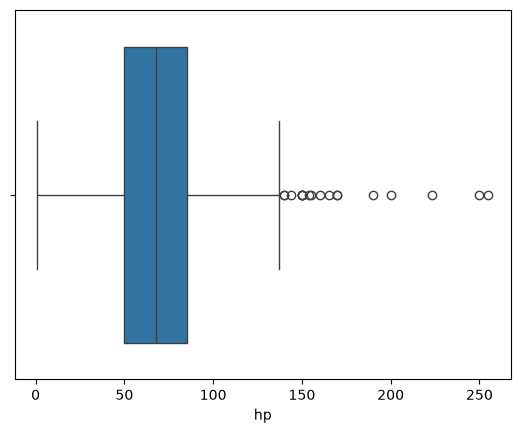

In [15]:
sns.boxplot(data=plot_df, x="hp")

In [16]:
# Extract HP values for each group as clean lists
hp_gen1_5 = plot_df[plot_df['gen_group'] == 'Gen 1-5']['hp'].tolist()
hp_gen6_9 = plot_df[plot_df['gen_group'] == 'Gen 6-9']['hp'].tolist()

# Print formatted as Desmos list variables
print(f"A = {hp_gen1_5}")
print("\n" + "="*50 + "\n")
print(f"B = {hp_gen6_9}")

A = [45, 60, 80, 39, 58, 78, 44, 59, 79, 45, 50, 60, 40, 45, 65, 40, 63, 83, 30, 55, 40, 65, 35, 60, 35, 60, 50, 75, 55, 70, 90, 46, 61, 81, 70, 95, 38, 73, 115, 140, 40, 75, 45, 60, 75, 35, 60, 60, 70, 10, 35, 40, 65, 50, 80, 40, 65, 55, 90, 40, 65, 90, 25, 40, 55, 70, 80, 90, 50, 65, 80, 40, 80, 40, 55, 80, 50, 65, 90, 95, 25, 50, 52, 35, 60, 65, 90, 80, 105, 30, 50, 30, 45, 60, 35, 60, 85, 30, 55, 40, 60, 60, 95, 50, 60, 50, 50, 90, 40, 65, 80, 105, 250, 65, 105, 30, 55, 45, 80, 30, 60, 40, 70, 65, 65, 65, 65, 75, 20, 95, 130, 48, 55, 130, 65, 65, 65, 35, 70, 30, 60, 80, 160, 90, 90, 90, 41, 61, 91, 106, 100, 45, 60, 80, 39, 58, 78, 50, 65, 85, 35, 85, 60, 100, 40, 55, 40, 70, 85, 75, 125, 20, 50, 90, 35, 55, 40, 65, 55, 70, 90, 75, 70, 100, 70, 90, 35, 55, 75, 55, 30, 75, 65, 55, 95, 65, 95, 60, 95, 60, 48, 190, 70, 50, 75, 100, 65, 75, 60, 90, 65, 70, 20, 80, 55, 60, 90, 40, 60, 50, 100, 65, 35, 75, 45, 85, 65, 45, 75, 75, 90, 90, 85, 73, 55, 35, 50, 45, 45, 45, 95, 255, 90, 115, 

## Conclusion:

### In my conclusion i found that the hp between the gen group 1-5 and gen group 6-9 are different by comparing the medians as you can see in the histogram above solid lines are the medians so now you can see that clearly the gen group 1-5 median is lower then the gen group 6-9 median. Median refers to the middle of the datasets literally the 50% in the dataset and as you can see in the histogram above the median of gen group 6-9 is bigger showing that later generations do have higher hps compared to gen group 1-5. You can even see the IQRs in the histogram above by the dotted lines these are more unaffected by outliers showing them to be more accurate ways to compare data and as you can see in the histogram above the IQR of the  gen group 6-9 is more to the left and bigger then gen group 1-5. more to the left means the hp in the IQR is higher which means IQR proves that gen group 6-9 along with the median shows that gen group 6-9 has higher on average higher hp then gen group 1-5. 

## Graph 

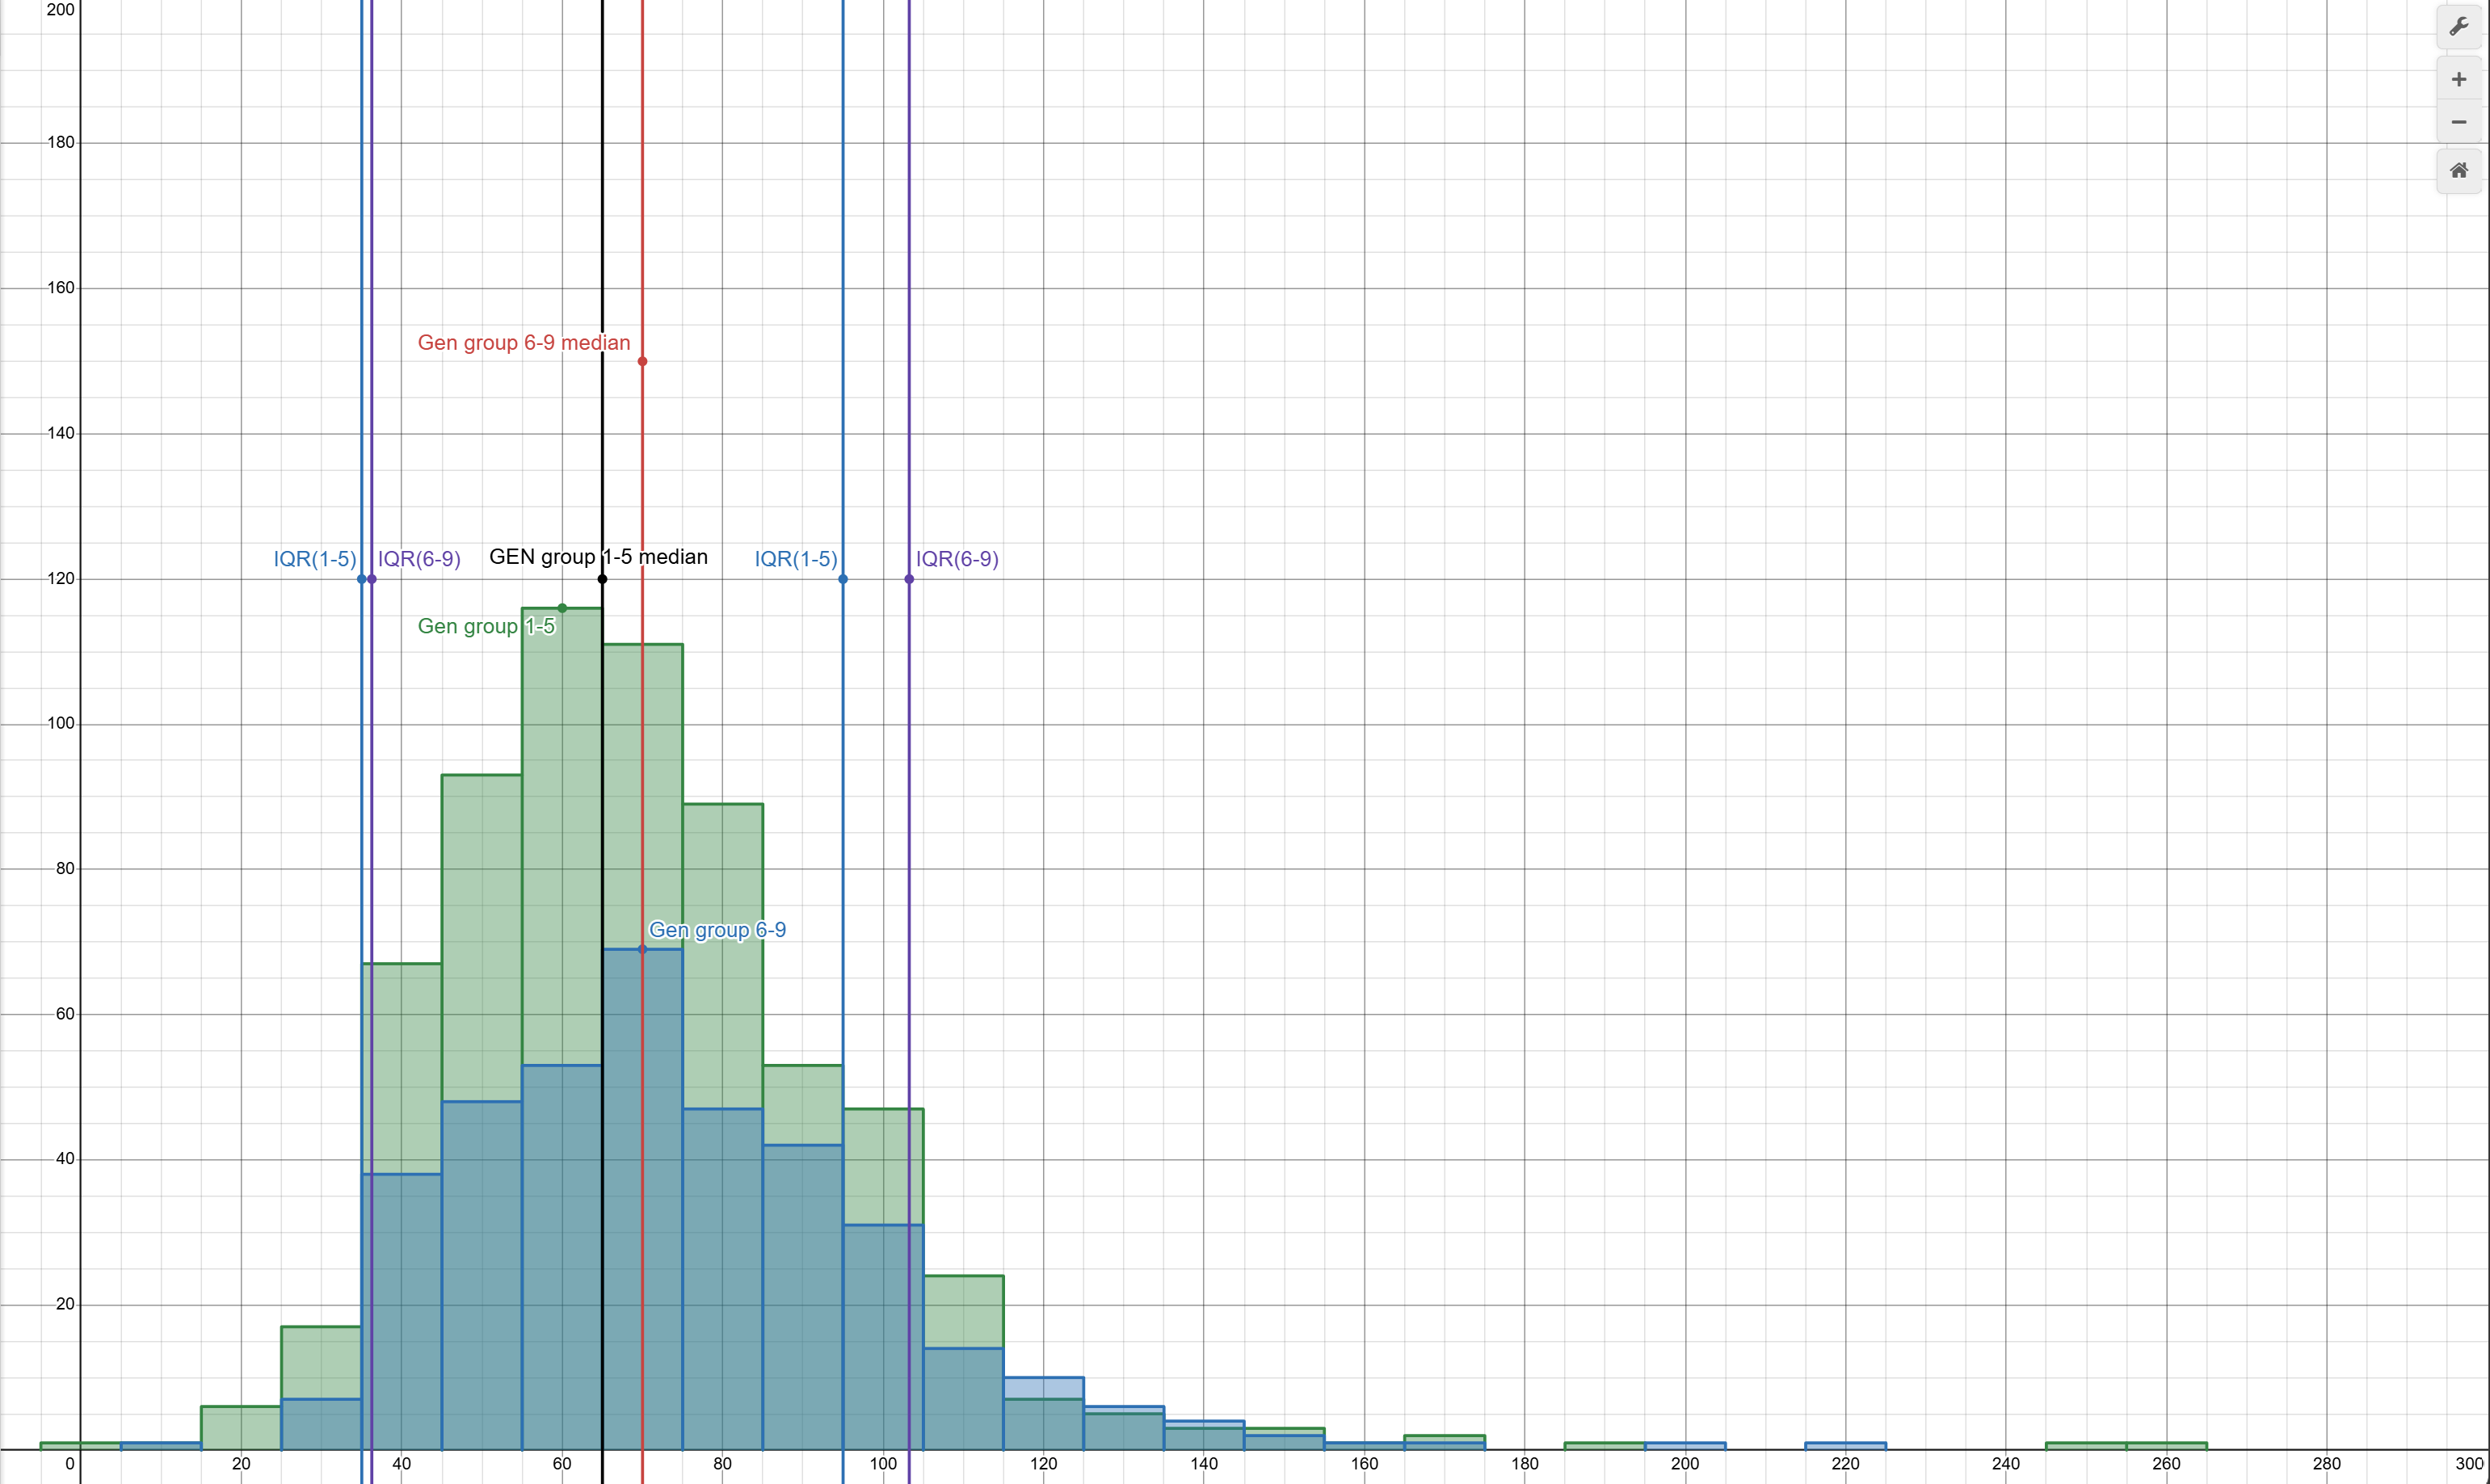

## Conclusion:

### Using my desmos graph to prove a point it labels the parts of the graph more better so readers can understand it more. As you can see both of these histograms are heavily right Skewed and the medians are the average of the data the 50% as you can see gen group 6-9 median is higher than gen group 1-5 median. But medians not what your looking for is it? It turns out you can use median for another thing its called IQR the IQR for 1-5 is 30 and the IQR for 6-9 is 33.25. So how does that matter? if you add IQR to median you get the max something normal could be and is you subtract IQR from median the minimum something normal could be. But as you can see we arent looking at a certain pokemon we are looking at the sizes of the IQR and how more to the right they are. If one groups IQR is more to the right then the other it means the IQR is greater proving that group hp is more higher compared to the other. As you can see the IQR of 6-9 is more to the right than the IQR of 1-5 which means gen group 6-9 has more hp than gen group 1-5.